# Graph Observation Spaces — IEEE 14-Bus Grid

Loads an observation from `l2rpn_case14_sandbox` **after a topology action that
splits substation 1** (generator 0 and line-origin 2 moved to bus 2).

All four converters are shown side-by-side. The two converters that encode
connectivity via edge metadata use `EdgeStyle` to colour edges:

| Converter | Colouring |
|---|---|
| `HeterogeneousGraphObservationConverter` | orange `--` = powerline · green = same-bus · crimson `:` = diff-bus |
| `ElementGraphObservationConverter` | green = active connection · gray = inactive |


In [1]:
import sys
from pathlib import Path

import grid2op
import matplotlib.pyplot as plt
from lightsim2grid import LightSimBackend

project_root = Path.cwd().parent.parent
src_root = project_root / "src"
for p in (str(project_root), str(src_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

from grid2op_env.observation_converter import (
    ElementGraphObservationConverter,
    GraphObservationConverter,
    HeterogeneousGraphObservationConverter,
    LODFGraphObservationConverter,
    PTDFGraphObservationConverter,
    SubstationGraphObservationConverter,
    ZbusGraphObservationConverter,
    EDGE_INDEX, EDGE_MASK, EDGES,
)
from visualization.utils import (
    PlottingArgs,
    get_node_styles,
    get_edge_styles,
    get_node_labels,
    get_edge_labels,
    get_substation_node_groups,
    get_curved_powerline_edges,
    visualize_graph,
)

plt.style.use("default")

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-26 17:12:31,550	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-26 17:12:34,359	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
env = grid2op.make("rte_case5_example", backend=LightSimBackend(), test=True)
env.reset()

action = env.action_space({
    "set_bus": {
        "generators_id": [(0, 2)],
        "lines_or_id":   [(2, 2), (3, 2)],
    }
})
obs, _, done, _ = env.step(action)
if done:
    print("Topology action caused game-over — using initial observation.")
    obs = env.reset()
else:
    print(f"Elements on bus 2: {(obs.topo_vect == 2).sum()}")

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:454: UserWarning: You are using a development environment. This environment is not intended for training agents. It might not be up to date and its primary use if for tests (hence the "test=True" you passed as argument). Use at your own risk.
  warnings.warn(_MAKE_DEV_ENV_WARN)


Elements on bus 2: 3


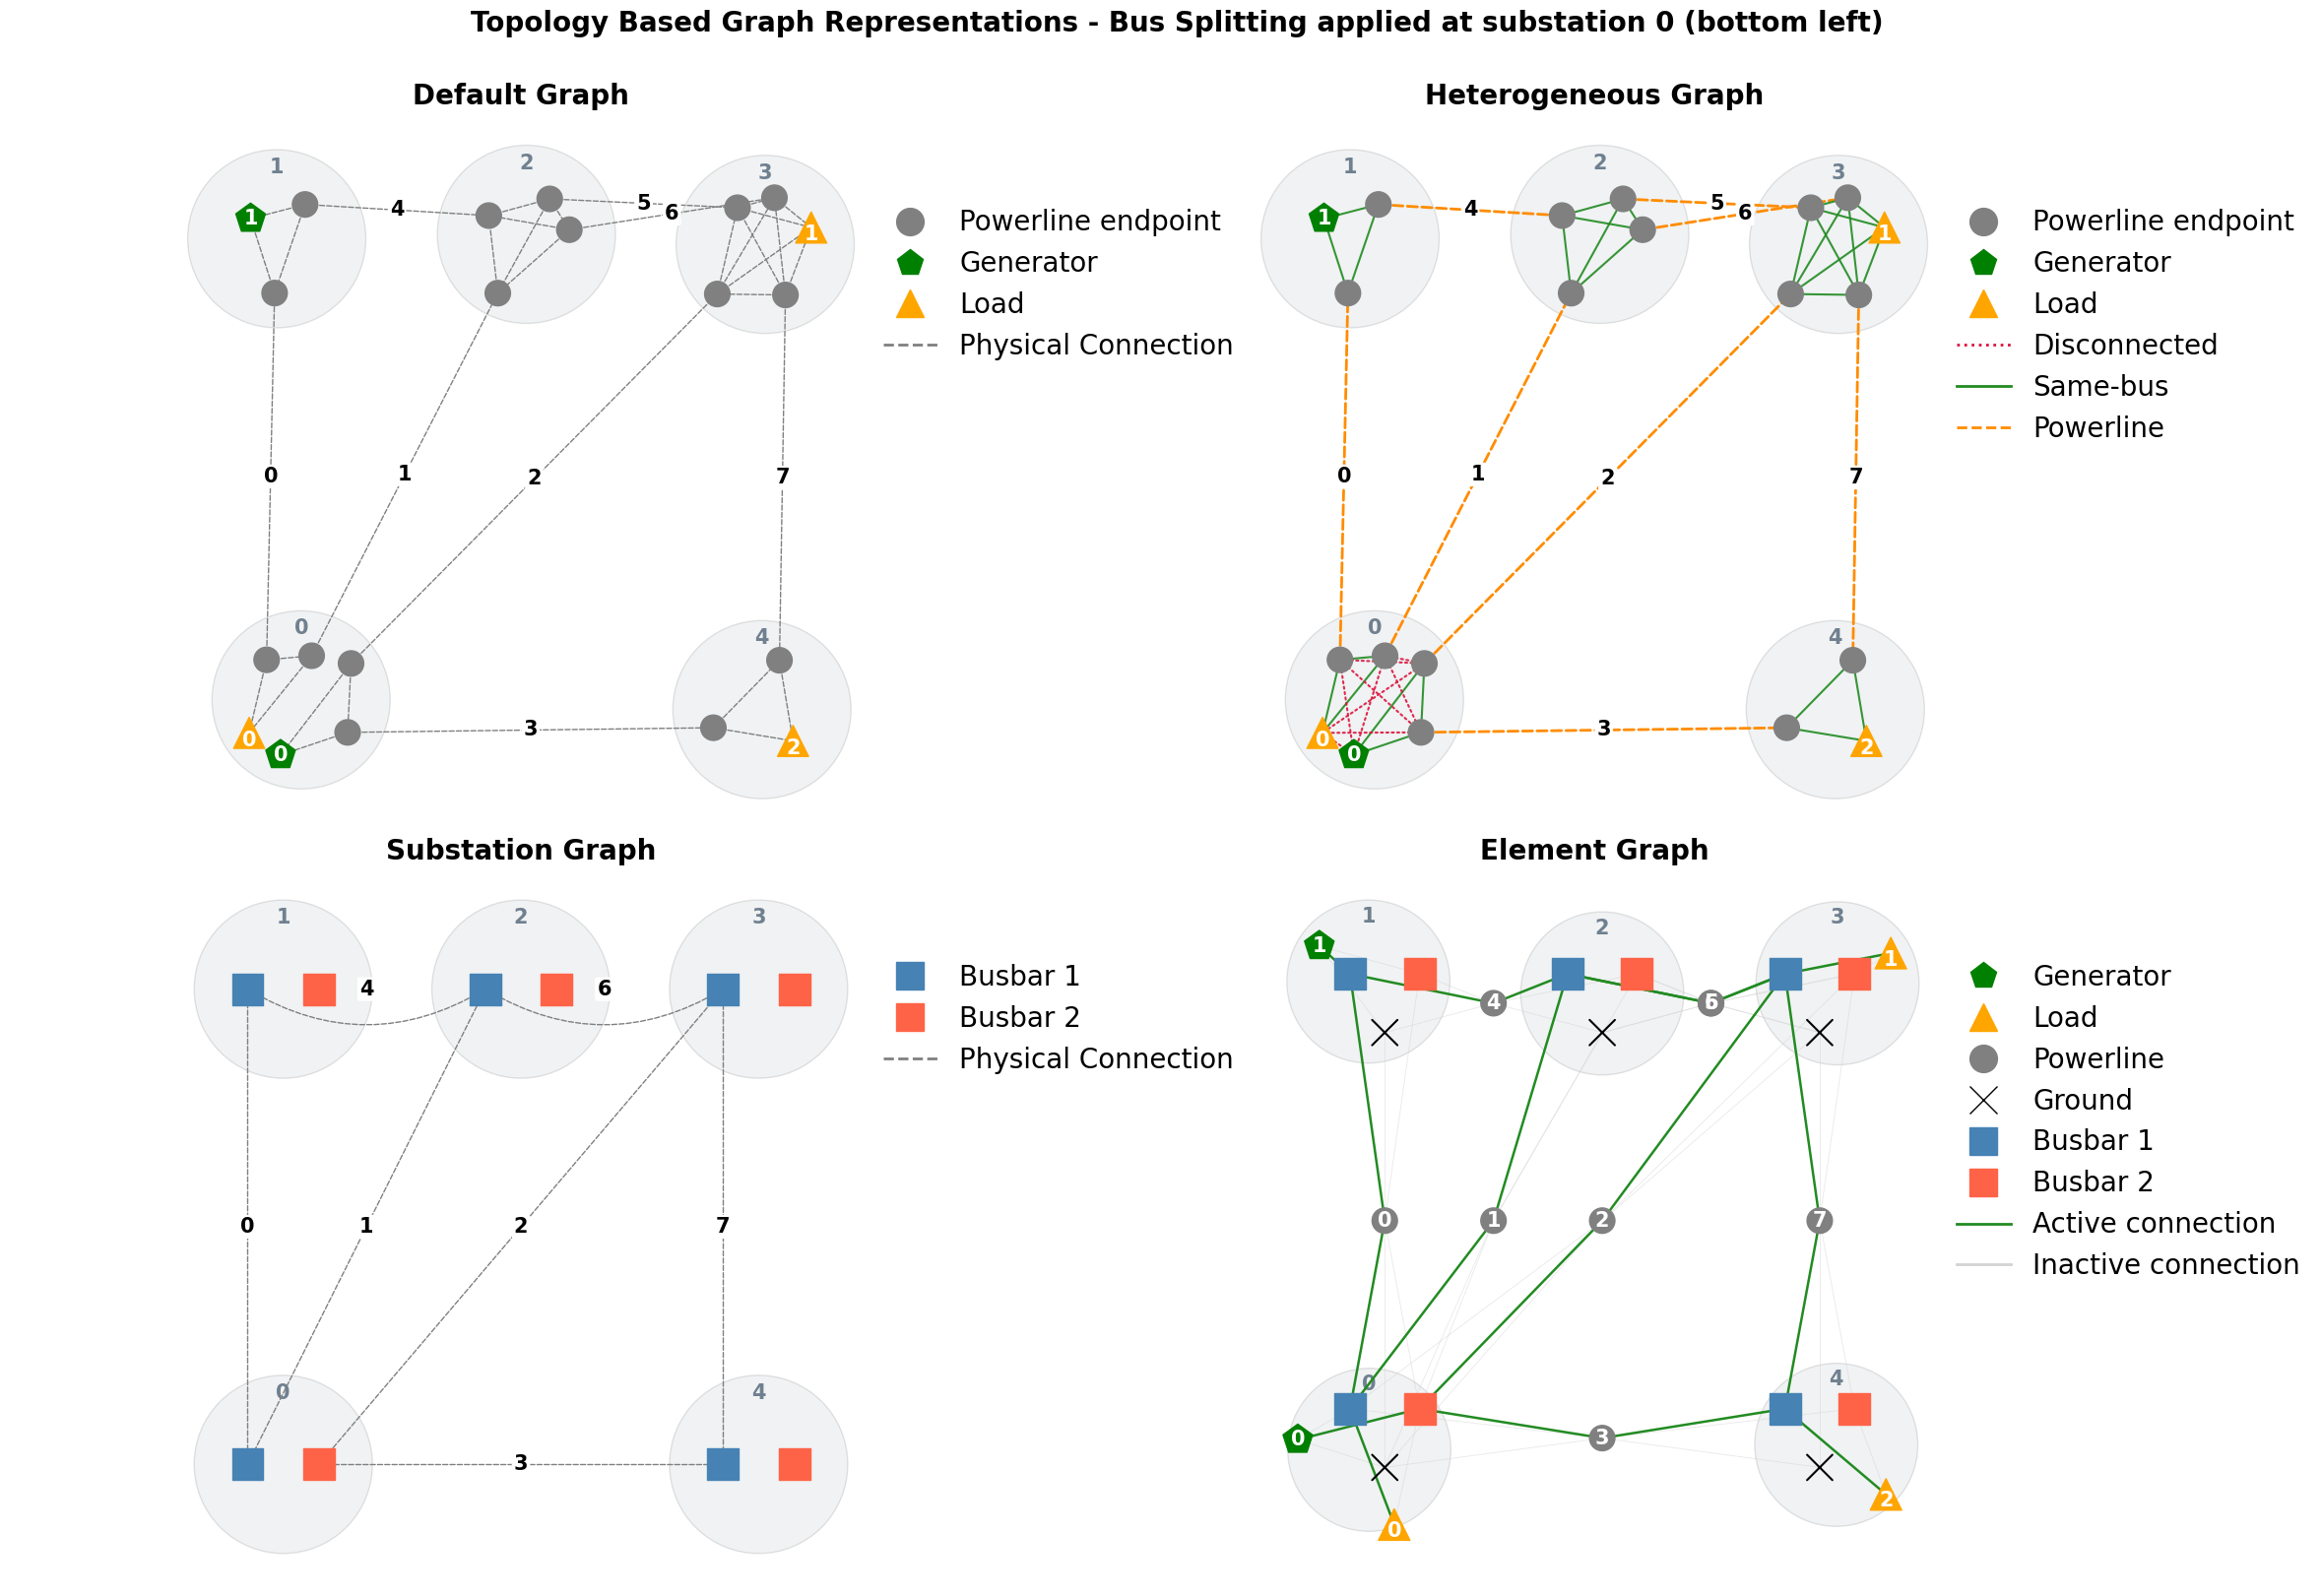

In [10]:
converters = [
    ("Default Graph",       GraphObservationConverter(env.observation_space)),
    ("Heterogeneous Graph", HeterogeneousGraphObservationConverter(env.observation_space)),
    ("Substation Graph",    SubstationGraphObservationConverter(env.observation_space)),
    ("Element Graph",       ElementGraphObservationConverter(env.observation_space)),
]

fig, axs = plt.subplots(2, 2, figsize=(24, 16), dpi=100)

for ax, (title, converter) in zip(axs.flat, converters):
    gym_obs       = converter.to_gym(obs)
    edge_mask     = gym_obs[EDGE_MASK].astype(bool)
    edge_index    = gym_obs[EDGE_INDEX][:, edge_mask]
    node_styles   = get_node_styles(env, type(converter))
    edge_styles   = get_edge_styles(gym_obs, type(converter))
    node_labels   = get_node_labels(env, type(converter))
    edge_labels   = get_edge_labels(env, obs, gym_obs, type(converter), edge_mask)
    sub_groups    = get_substation_node_groups(env, type(converter))
    curved_edges  = get_curved_powerline_edges(env, obs, type(converter), [4, 6])

    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=edge_index,
        node_styles=node_styles,
        edge_styles=edge_styles,
        node_labels=node_labels,
        edge_labels=edge_labels,
        substation_node_groups=sub_groups,
        curved_edges=curved_edges,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=20, fontweight="bold")

plt.suptitle(
    "Topology Based Graph Representations - Bus Splitting applied at substation 0 (bottom left)",
    fontsize=20, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.savefig("topology_based_representations.png", dpi=100)
plt.show()

## Topology- and Impedance-based Graph Representations

The three converters below require a **LightSimBackend** environment (PTDF, LODF, and Ybus are computed directly from the C++ grid model).

Edges are **fully connected** — every pair of buses (PTDF, Zbus) or every pair of lines (LODF) is connected.
Only the **top-K strongest edges** are shown to keep the plot readable; edge colour and width encode relative coupling strength (yellow → red = weak → strong).

| Converter | Nodes | Edge weight |
|---|---|---|
| `PTDFGraphObservationConverter` | Buses (2 × n_sub) | L1 PTDF distance (lower = more similar electrical response) |
| `LODFGraphObservationConverter` | Lines | \|LODF[i,j]\| (higher = stronger contingency coupling) |
| `ZbusGraphObservationConverter` | Buses (2 × n_sub) | 1 / \|Zbus[i,j]\| (higher = electrically closer) |

Elements on bus 2: 2


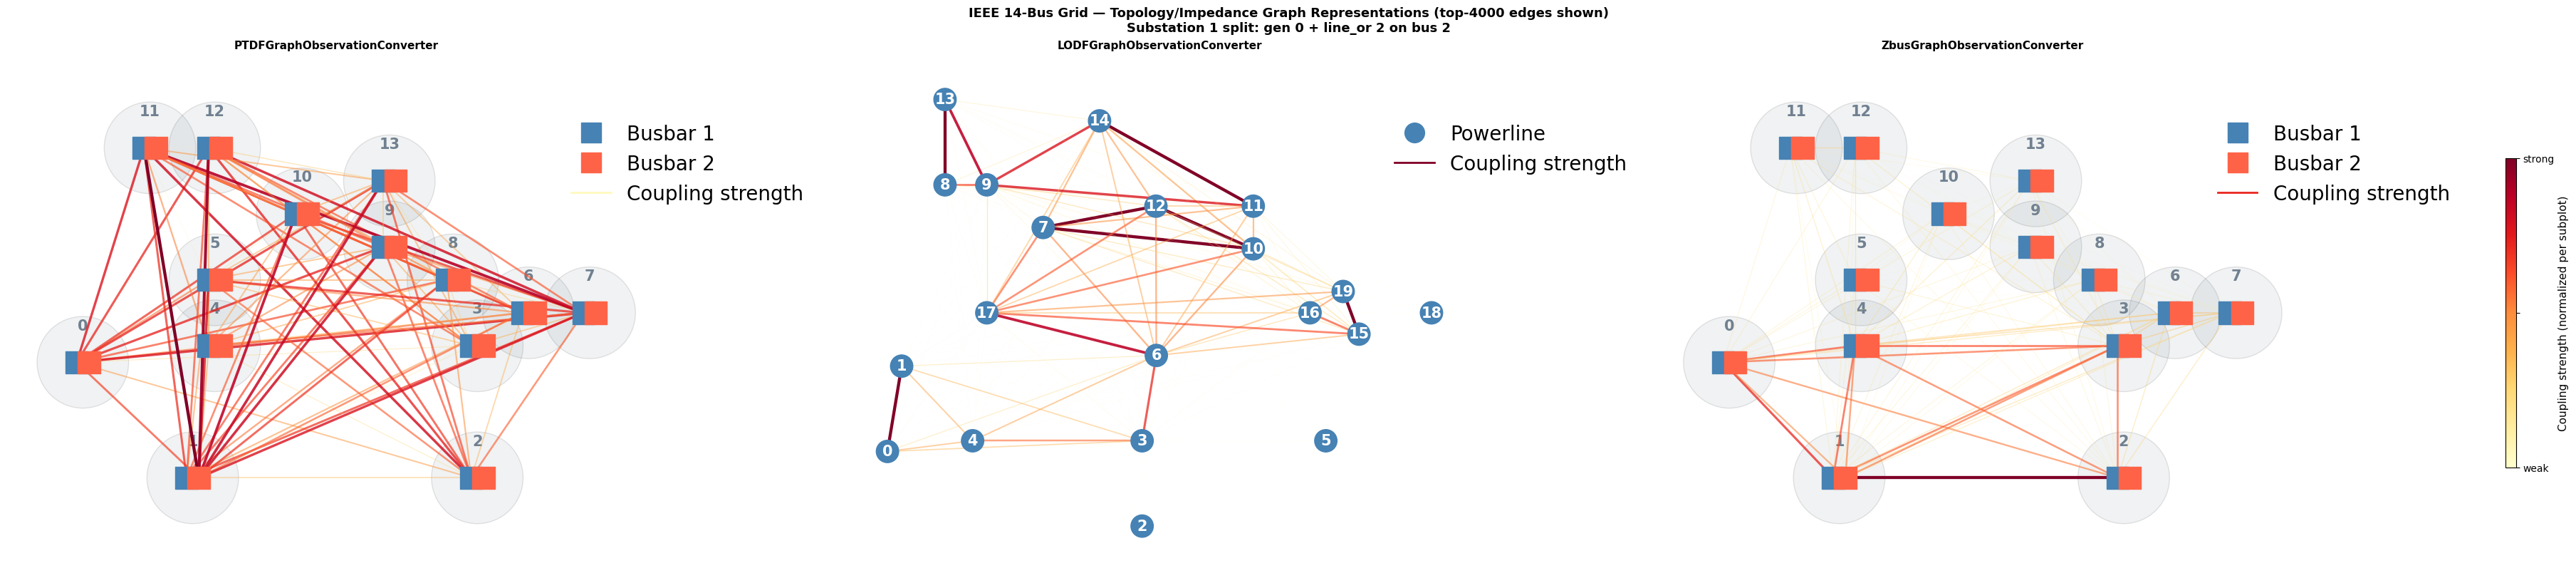

In [4]:
import numpy as np
import matplotlib.cm as mcm
import matplotlib.colors as mcolors_norm

# LightSimBackend environment — required for PTDF/LODF/Zbus computation.
env_ls = grid2op.make("l2rpn_case14_sandbox", backend=LightSimBackend())
env_ls.reset()

action_ls = env_ls.action_space({
    "set_bus": {
        "generators_id": [(0, 2)],
        "lines_or_id":   [(2, 2)],
    }
})
obs_ls, _, done_ls, _ = env_ls.step(action_ls)
if done_ls:
    print("Topology action caused game-over — using initial observation.")
    obs_ls = env_ls.reset()
else:
    print(f"Elements on bus 2: {(obs_ls.topo_vect == 2).sum()}")

TOP_K = 4000  # number of strongest edges to display per converter

converters_ls = [
    ("PTDFGraphObservationConverter",
     PTDFGraphObservationConverter(env_ls.backend, env_ls.observation_space)),
    ("LODFGraphObservationConverter",
     LODFGraphObservationConverter(env_ls.backend, env_ls.observation_space)),
    ("ZbusGraphObservationConverter",
     ZbusGraphObservationConverter(env_ls.backend, env_ls.observation_space)),
]

fig, axs = plt.subplots(1, 3, figsize=(36, 8), dpi=100, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.01, wspace=0.02)

for ax, (title, converter) in zip(axs, converters_ls):
    gym_obs = converter.to_gym(obs_ls)

    active_mask = gym_obs[EDGE_MASK].astype(bool)
    weights_all = np.nan_to_num(np.abs(gym_obs[EDGES][:, 0]))
    active_idx  = np.where(active_mask)[0]
    top_idx     = active_idx[np.argsort(weights_all[active_idx])[-TOP_K:]]
    top_k_mask  = np.zeros(len(active_mask), dtype=bool)
    top_k_mask[top_idx] = True

    edge_index   = gym_obs[EDGE_INDEX][:, top_k_mask]
    node_styles  = get_node_styles(env_ls, type(converter))
    edge_styles  = get_edge_styles(gym_obs, type(converter), edge_mask=top_k_mask)
    node_labels  = get_node_labels(env_ls, type(converter))
    edge_labels  = get_edge_labels(env_ls, obs_ls, gym_obs, type(converter), top_k_mask)
    sub_groups   = get_substation_node_groups(env_ls, type(converter))

    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=edge_index,
        node_styles=node_styles,
        edge_styles=edge_styles,
        node_labels=node_labels,
        edge_labels=edge_labels,
        substation_node_groups=sub_groups,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=11, fontweight="bold")

sm = mcm.ScalarMappable(cmap="YlOrRd", norm=mcolors_norm.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.02)
cbar.set_label("Coupling strength (normalized per subplot)", fontsize=11)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(["weak", "", "strong"])

plt.suptitle(
    f"IEEE 14-Bus Grid — Topology/Impedance Graph Representations (top-{TOP_K} edges shown)\n"
    "Substation 1 split: gen 0 + line_or 2 on bus 2",
    fontsize=13, fontweight="bold",
)
plt.show()

## Combined Observation Spaces

Each of the three converters below layers a physics-driven edge type on top of a base graph topology:

| Converter | Base nodes | Type-0 edges | Type-1 edges |
|---|---|---|---|
| `ElementLODFGraphObservationConverter` | Elements (gen, load, line, storage, bus) | element → busbar (binary active) | LODF coupling: line[i] → line[j] |
| `SubstationPTDFGraphObservationConverter` | Busbars (2 × n_sub) | powerline topology | PTDF distance: all bus pairs |
| `SubstationZbusGraphObservationConverter` | Busbars (2 × n_sub) | powerline topology | Zbus admittance: all bus pairs |

Only the **top-K strongest physics edges** (type 1) are shown; type-0 topology edges are always shown in full.

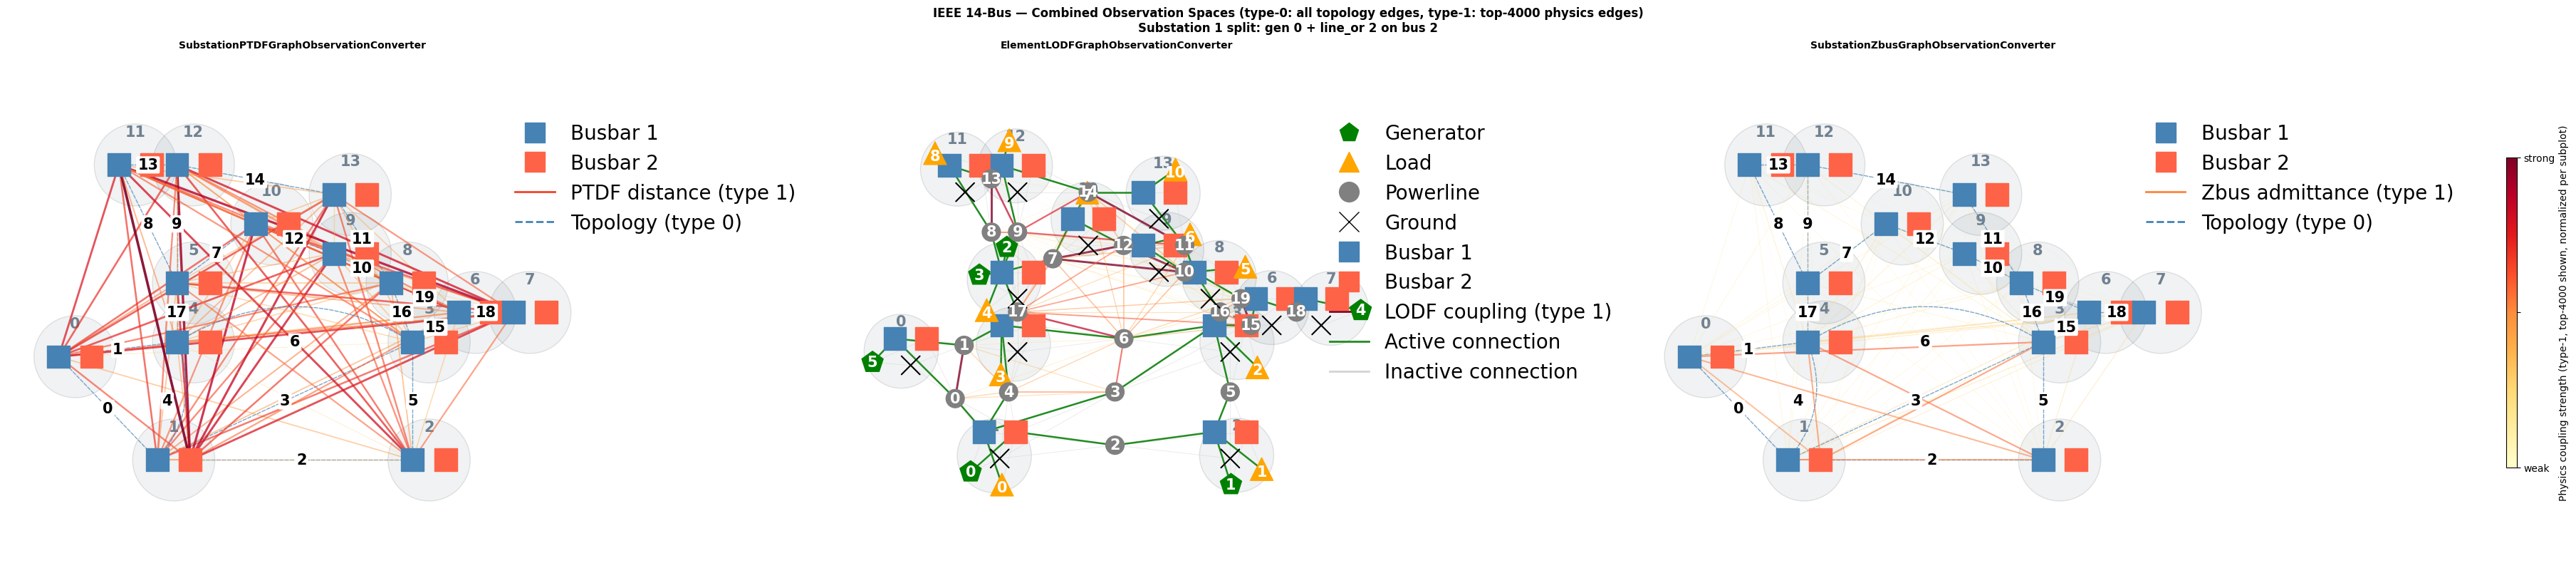

In [5]:
import numpy as np
from grid2op_env.observation_converter import (
    ElementLODFGraphObservationConverter,
    SubstationPTDFGraphObservationConverter,
    SubstationZbusGraphObservationConverter,
    EDGE_TYPE,
)

TOP_K = 4000  # strongest type-1 edges to display per converter

converters_combined = [
    ("SubstationPTDFGraphObservationConverter",
     SubstationPTDFGraphObservationConverter(
         backend=env_ls.backend, g2op_obs_space=env_ls.observation_space)),
    ("ElementLODFGraphObservationConverter",
     ElementLODFGraphObservationConverter(
         backend=env_ls.backend, g2op_obs_space=env_ls.observation_space)),
    ("SubstationZbusGraphObservationConverter",
     SubstationZbusGraphObservationConverter(
         backend=env_ls.backend, g2op_obs_space=env_ls.observation_space)),
]

fig, axs = plt.subplots(1, 3, figsize=(36, 8), dpi=100, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.01, wspace=0.02)

for ax, (title, converter) in zip(axs, converters_combined):
    gym_obs   = converter.to_gym(obs_ls)
    conv_type = type(converter)

    active_mask  = gym_obs[EDGE_MASK].astype(bool)
    edge_types   = gym_obs[EDGE_TYPE]
    edge_weights = np.nan_to_num(np.abs(gym_obs[EDGES][:, 0]))

    topo_mask = active_mask & (edge_types == 0)
    phys_idx  = np.where(active_mask & (edge_types == 1))[0]
    top_idx   = phys_idx[np.argsort(edge_weights[phys_idx])[-TOP_K:]]
    phys_mask = np.zeros(len(active_mask), dtype=bool)
    phys_mask[top_idx] = True
    display_mask = topo_mask | phys_mask

    node_styles  = get_node_styles(env_ls, conv_type)
    edge_styles  = get_edge_styles(gym_obs, conv_type, edge_mask=display_mask)
    node_labels  = get_node_labels(env_ls, conv_type)
    edge_labels  = get_edge_labels(env_ls, obs_ls, gym_obs, conv_type, display_mask)
    sub_groups   = get_substation_node_groups(env_ls, conv_type)
    curved_edges = get_curved_powerline_edges(env_ls, obs_ls, conv_type, [4, 6])

    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=gym_obs[EDGE_INDEX][:, display_mask],
        node_styles=node_styles,
        edge_styles=edge_styles,
        node_labels=node_labels,
        edge_labels=edge_labels,
        substation_node_groups=sub_groups,
        curved_edges=curved_edges,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=10, fontweight="bold")

sm = mcm.ScalarMappable(cmap="YlOrRd", norm=mcolors_norm.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.02)
cbar.set_label(f"Physics coupling strength (type-1, top-{TOP_K} shown, normalized per subplot)", fontsize=10)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.set_ticklabels(["weak", "", "strong"])

plt.suptitle(
    f"IEEE 14-Bus — Combined Observation Spaces (type-0: all topology edges, type-1: top-{TOP_K} physics edges)\n"
    "Substation 1 split: gen 0 + line_or 2 on bus 2",
    fontsize=12, fontweight="bold",
)
plt.show()

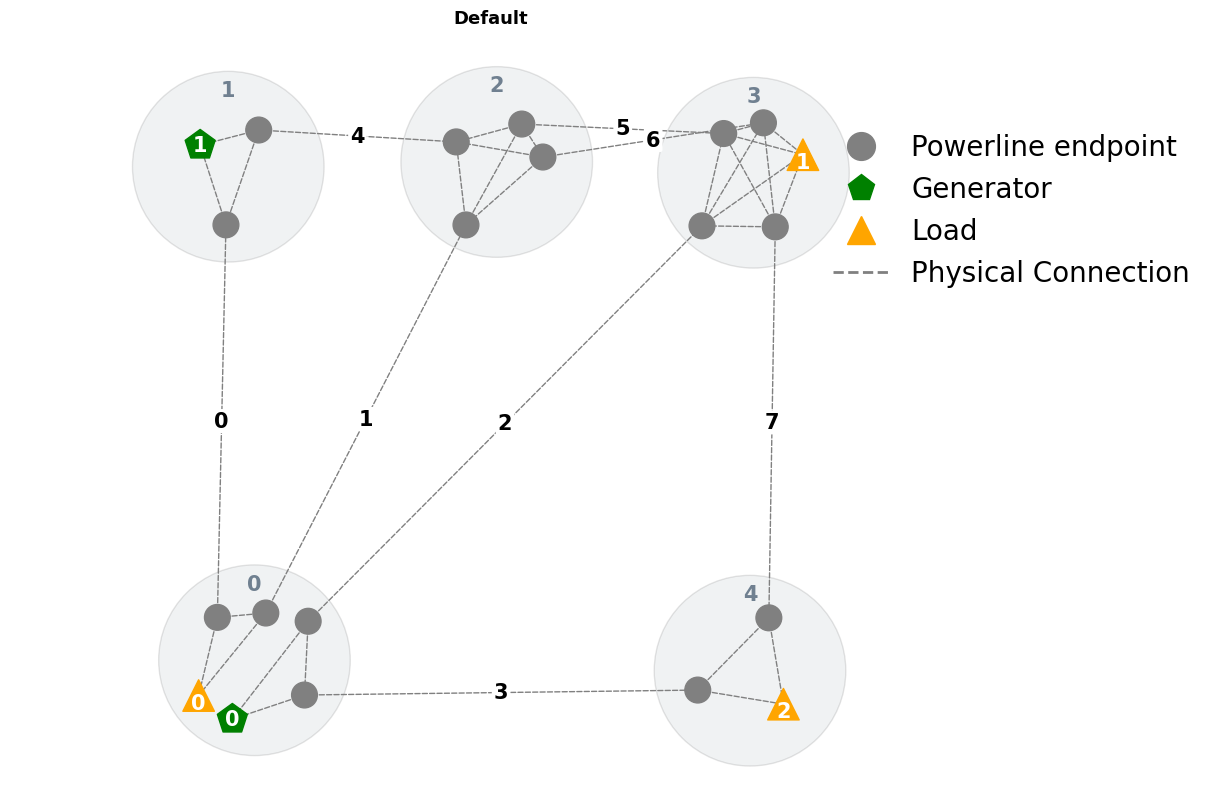

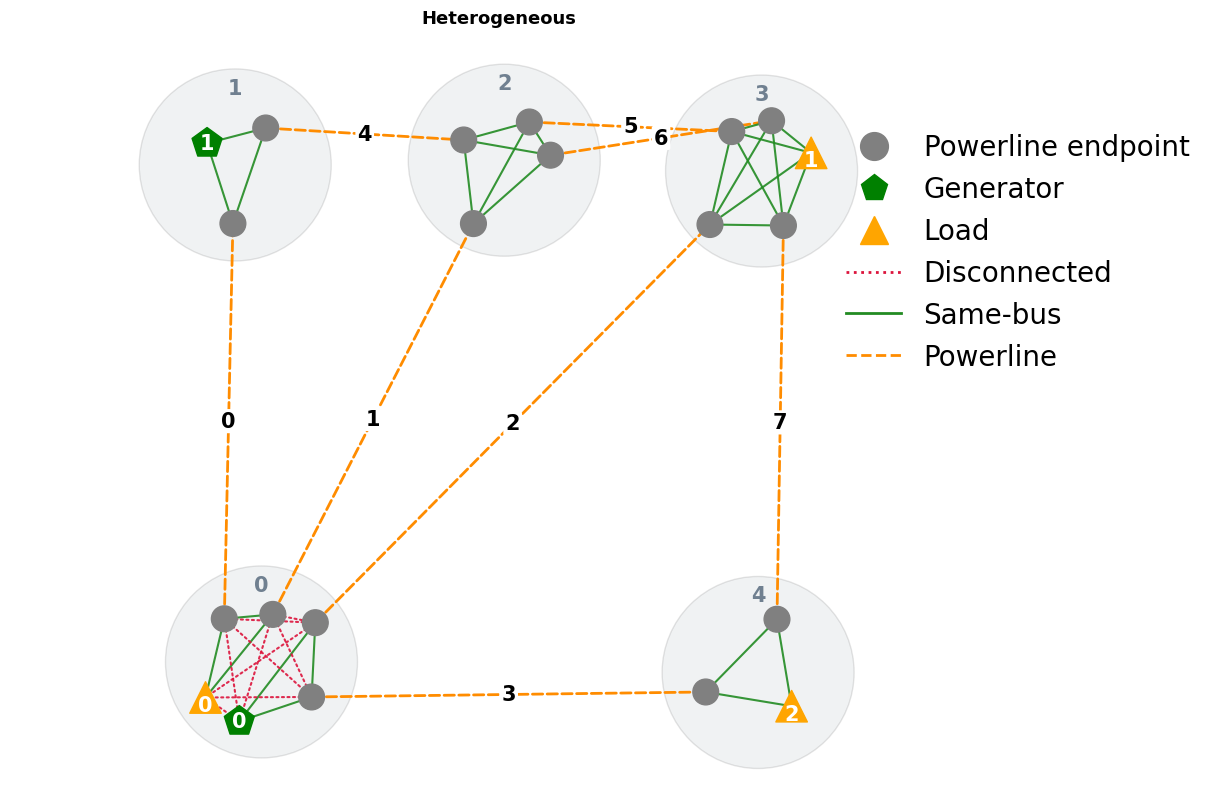

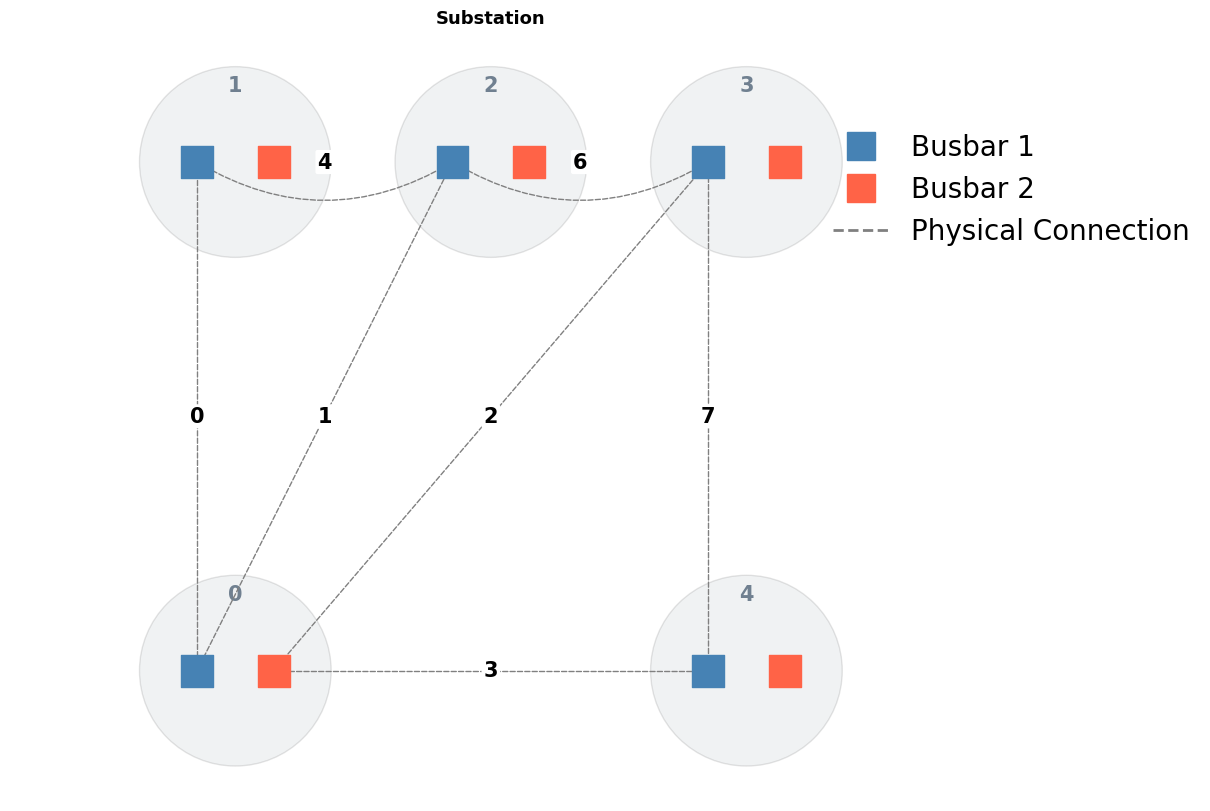

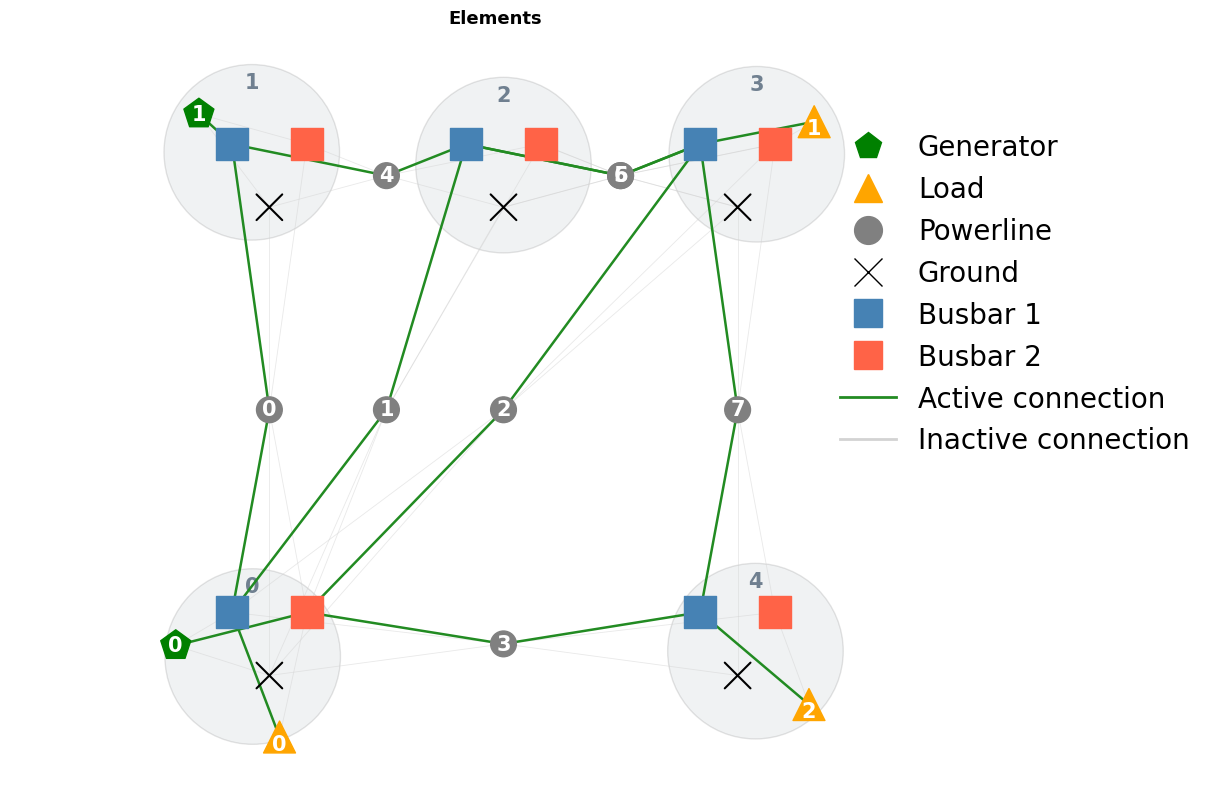

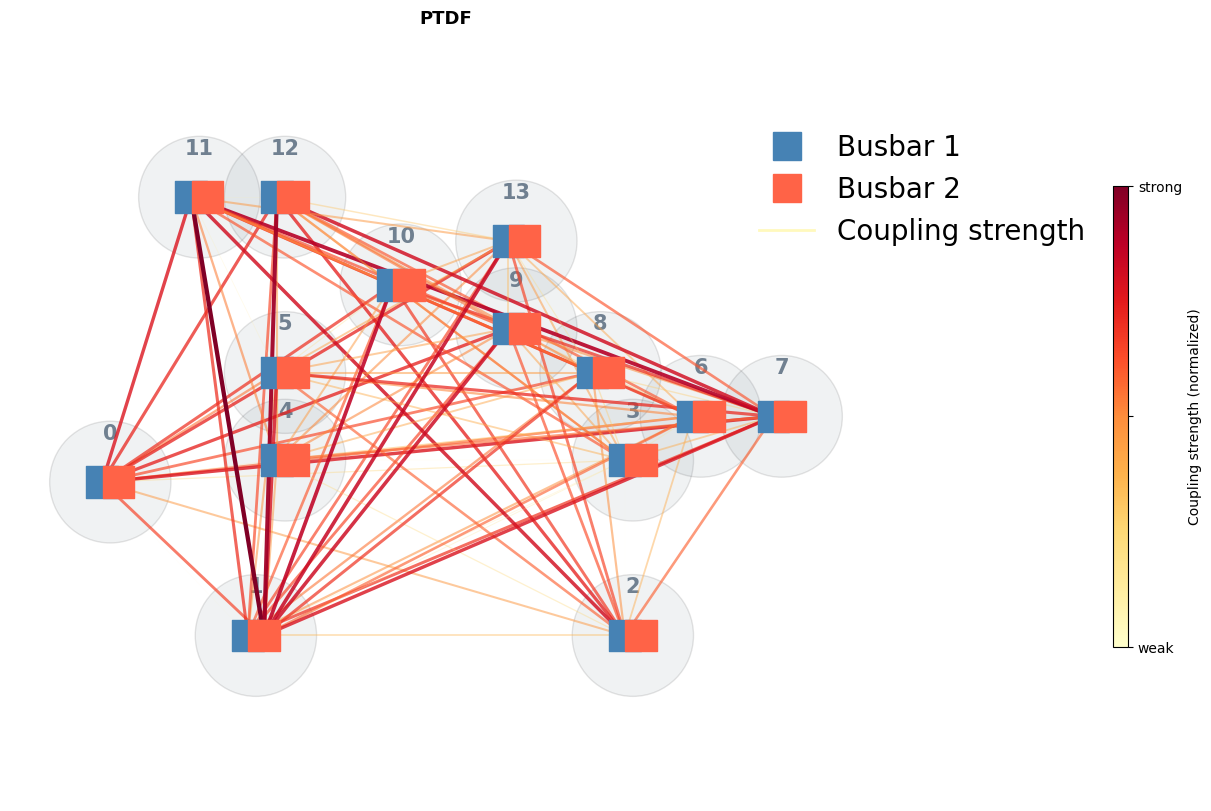

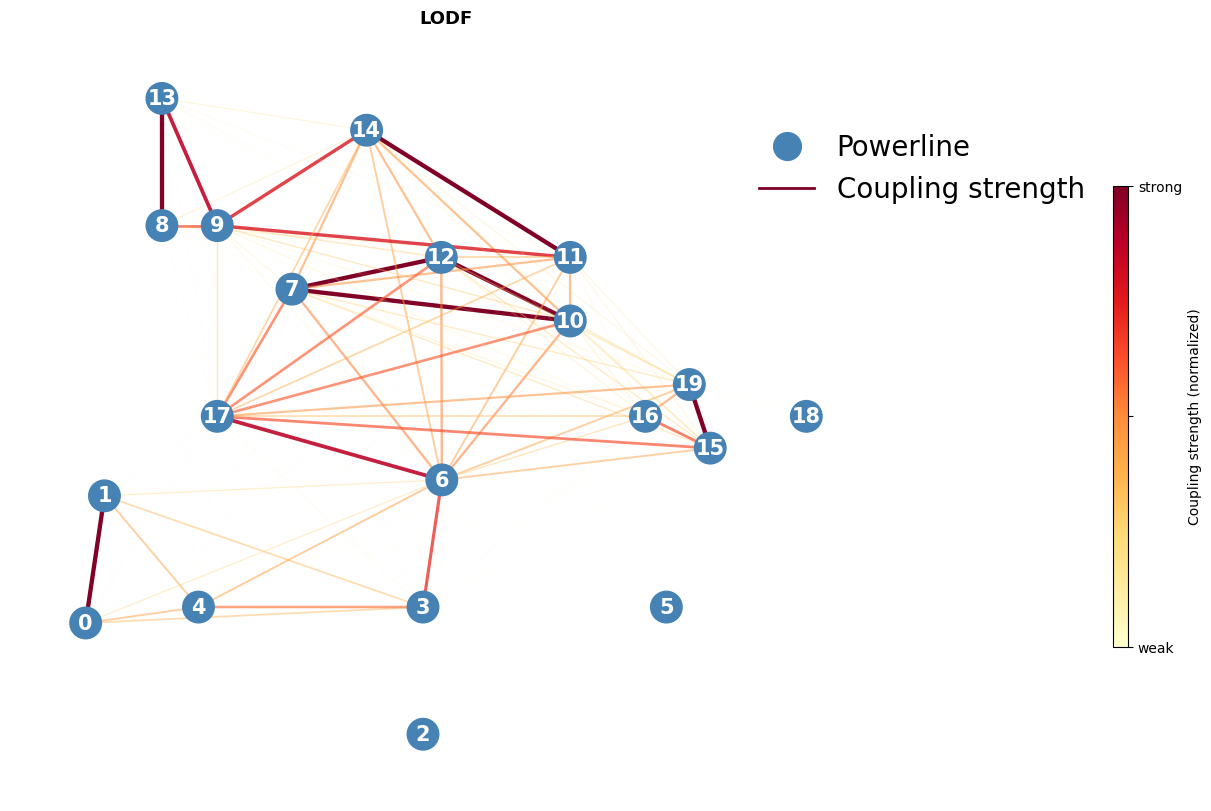

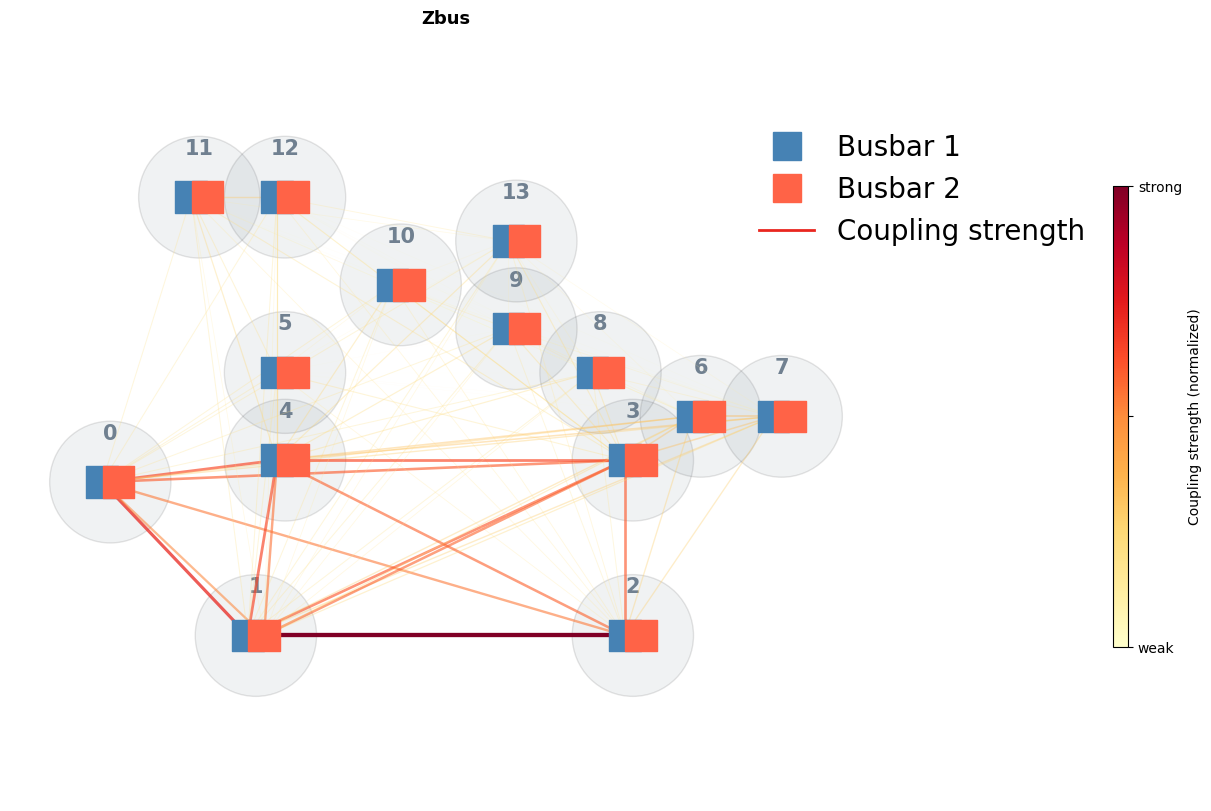

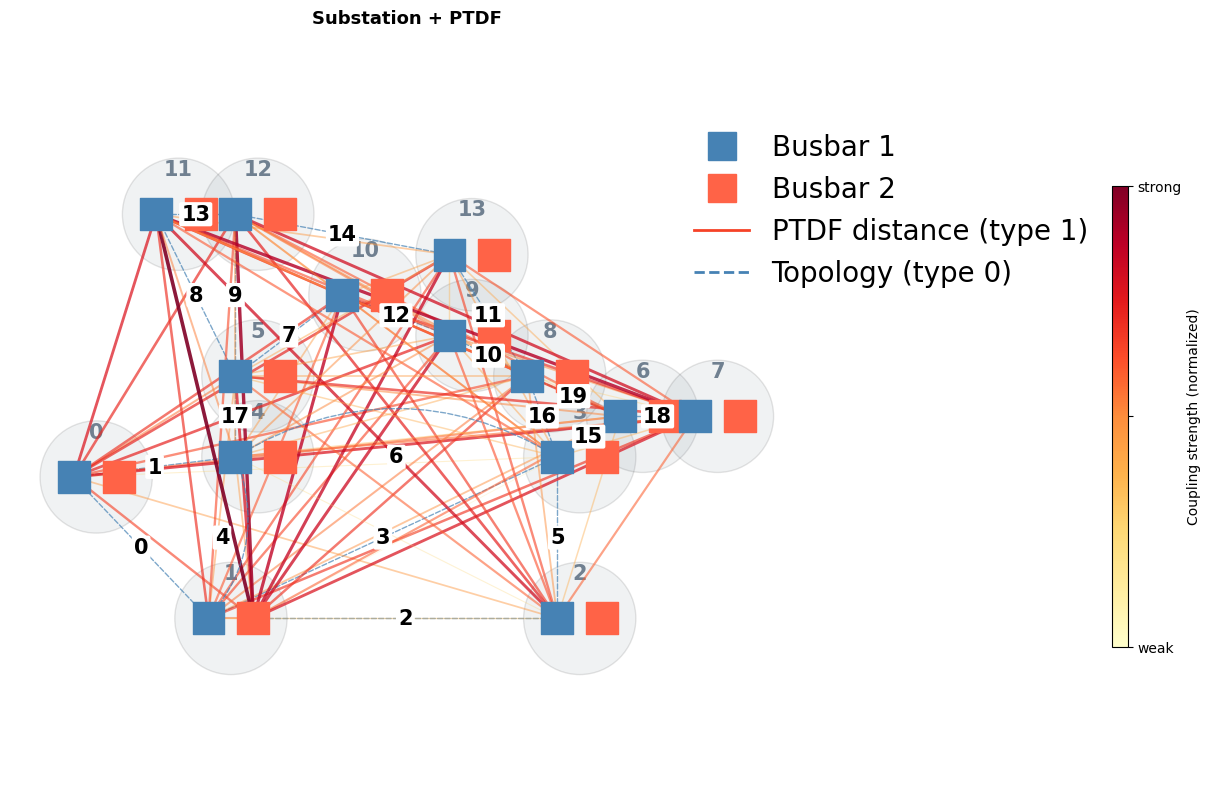

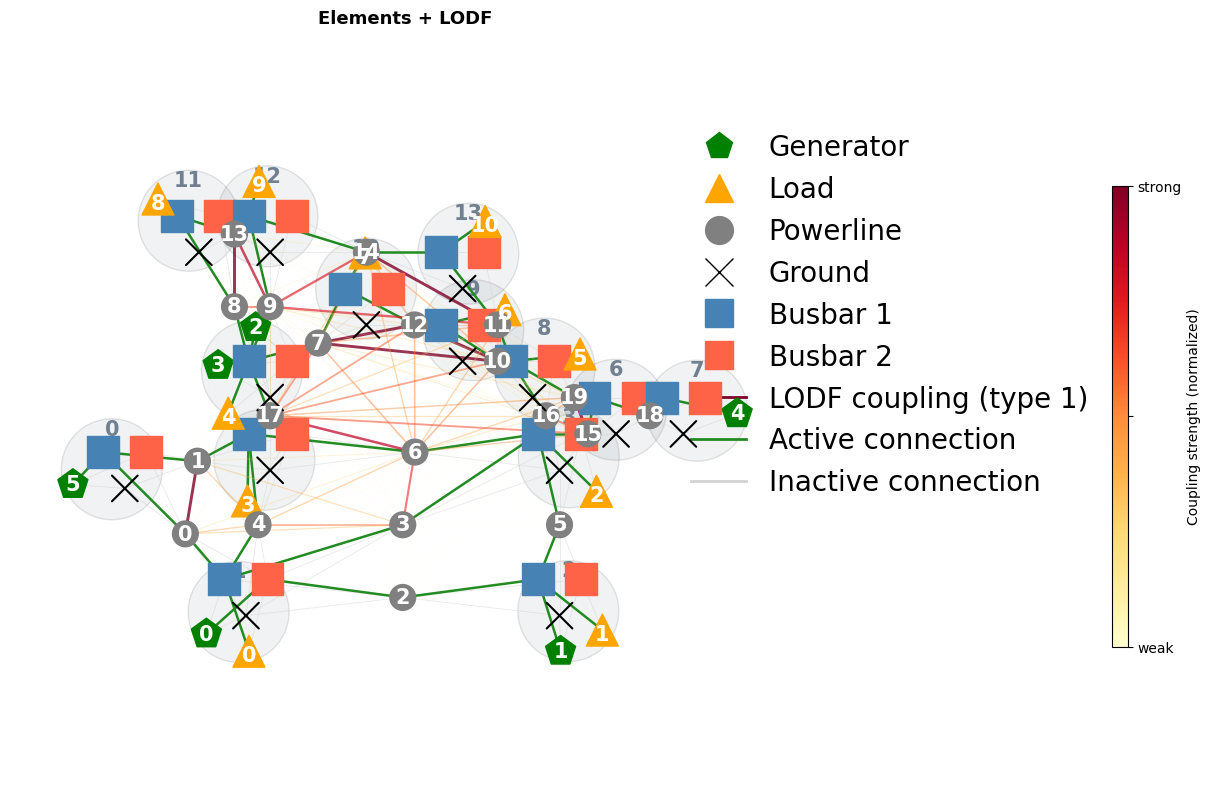

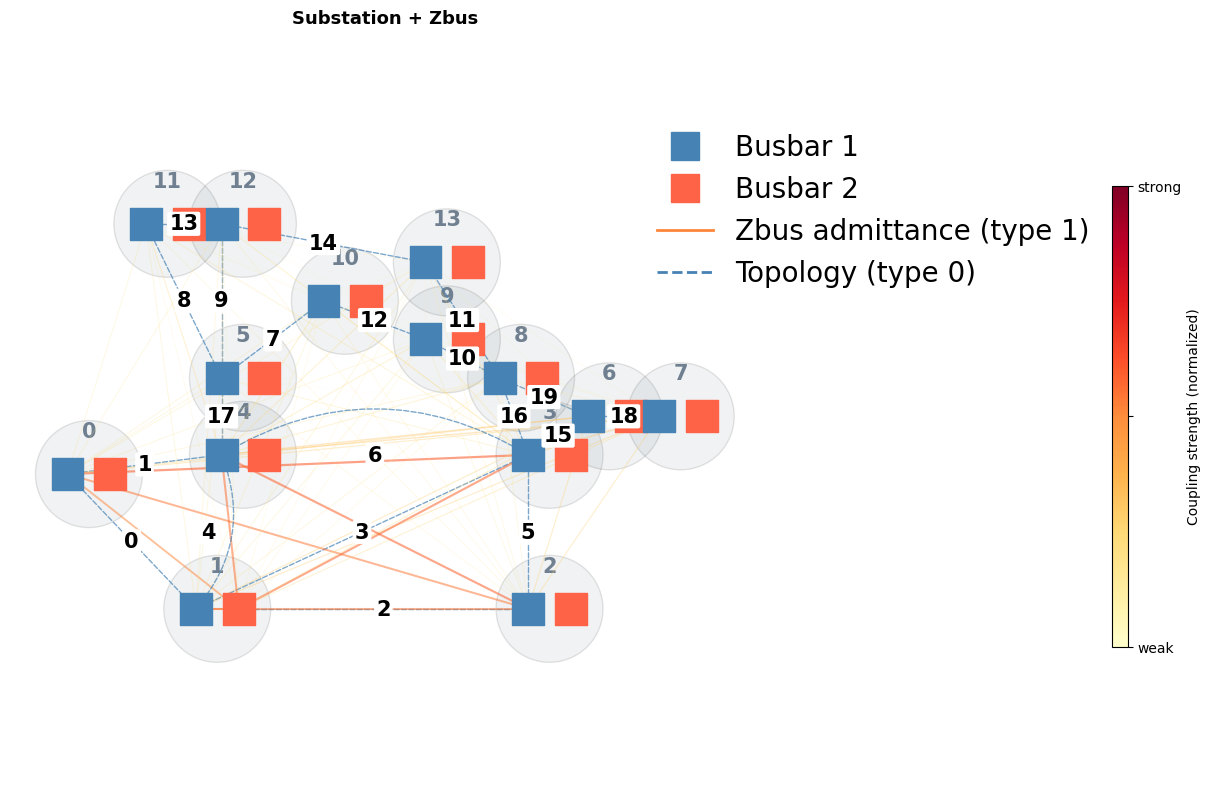

In [6]:
# ── Individual plots — one figure per observation space ───────────────────────
import numpy as np
import matplotlib.cm as mcm
import matplotlib.colors as mcolors_norm
from grid2op_env.observation_converter import (
    ElementLODFGraphObservationConverter,
    SubstationPTDFGraphObservationConverter,
    SubstationZbusGraphObservationConverter,
    EDGE_TYPE,
)

TOP_K = 4000

_PHYSICS_TYPES  = (PTDFGraphObservationConverter, LODFGraphObservationConverter,
                   ZbusGraphObservationConverter)
_COMBINED_TYPES = (ElementLODFGraphObservationConverter,
                   SubstationPTDFGraphObservationConverter,
                   SubstationZbusGraphObservationConverter)

# (display label, converter instance, environment, observation)
all_converters_individual = [
    ("Default",
     GraphObservationConverter(env.observation_space),
     env, obs),
    ("Heterogeneous",
     HeterogeneousGraphObservationConverter(env.observation_space),
     env, obs),
    ("Substation",
     SubstationGraphObservationConverter(env.observation_space),
     env, obs),
    ("Elements",
     ElementGraphObservationConverter(env.observation_space),
     env, obs),
    ("PTDF",
     PTDFGraphObservationConverter(env_ls.backend, env_ls.observation_space),
     env_ls, obs_ls),
    ("LODF",
     LODFGraphObservationConverter(env_ls.backend, env_ls.observation_space),
     env_ls, obs_ls),
    ("Zbus",
     ZbusGraphObservationConverter(env_ls.backend, env_ls.observation_space),
     env_ls, obs_ls),
    ("Substation + PTDF",
     SubstationPTDFGraphObservationConverter(env_ls.backend, env_ls.observation_space),
     env_ls, obs_ls),
    ("Elements + LODF",
     ElementLODFGraphObservationConverter(env_ls.backend, env_ls.observation_space),
     env_ls, obs_ls),
    ("Substation + Zbus",
     SubstationZbusGraphObservationConverter(env_ls.backend, env_ls.observation_space),
     env_ls, obs_ls),
]

for label, converter, _env, _obs in all_converters_individual:
    gym_obs     = converter.to_gym(_obs)
    active_mask = gym_obs[EDGE_MASK].astype(bool)
    conv_type   = type(converter)

    if isinstance(converter, _COMBINED_TYPES):
        edge_types   = gym_obs[EDGE_TYPE]
        edge_weights = np.nan_to_num(np.abs(gym_obs[EDGES][:, 0]))
        topo_mask    = active_mask & (edge_types == 0)
        phys_idx     = np.where(active_mask & (edge_types == 1))[0]
        top_idx      = phys_idx[np.argsort(edge_weights[phys_idx])[-TOP_K:]]
        phys_mask    = np.zeros(len(active_mask), dtype=bool)
        phys_mask[top_idx] = True
        display_mask = topo_mask | phys_mask
        has_colorbar = True
    elif isinstance(converter, _PHYSICS_TYPES):
        edge_weights = np.nan_to_num(np.abs(gym_obs[EDGES][:, 0]))
        active_idx   = np.where(active_mask)[0]
        top_idx      = active_idx[np.argsort(edge_weights[active_idx])[-TOP_K:]]
        display_mask = np.zeros(len(active_mask), dtype=bool)
        display_mask[top_idx] = True
        has_colorbar = True
    else:
        display_mask = active_mask
        has_colorbar = False

    node_styles  = get_node_styles(_env, conv_type)
    edge_styles  = get_edge_styles(gym_obs, conv_type, edge_mask=display_mask)
    node_labels  = get_node_labels(_env, conv_type)
    edge_labels  = get_edge_labels(_env, _obs, gym_obs, conv_type, display_mask)
    sub_groups   = get_substation_node_groups(_env, conv_type)
    curved_edges = get_curved_powerline_edges(_env, _obs, conv_type, [4, 6])

    fig, ax = plt.subplots(figsize=(12, 8), dpi=100, constrained_layout=True)
    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=gym_obs[EDGE_INDEX][:, display_mask],
        node_styles=node_styles,
        edge_styles=edge_styles,
        node_labels=node_labels,
        edge_labels=edge_labels,
        substation_node_groups=sub_groups,
        curved_edges=curved_edges,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)

    if has_colorbar:
        sm = mcm.ScalarMappable(cmap="YlOrRd", norm=mcolors_norm.Normalize(vmin=0, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=30, pad=0.02)
        cbar.set_label("Coupling strength (normalized)", fontsize=10)
        cbar.set_ticks([0.0, 0.5, 1.0])
        cbar.set_ticklabels(["weak", "", "strong"])

    ax.set_title(label, fontsize=13, fontweight="bold")
    plt.show()